# Telco Customer Churn Analysis

End-to-end exploratory data analysis of telecom customer churn using **Python** (Pandas, NumPy, Matplotlib, Seaborn) and **SQLite**.

**Dataset:** 7,043 customer records, 21 columns.

**Objectives**
- Identify churn drivers
- Segment churn by contract, internet service, and payment method
- Explore tenure and monthly-charge patterns
- Translate analysis into retention insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/telco_churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")


Missing values per column:
0 total missing values


## Overall Churn Rate

Overall churn rate: 31.0%


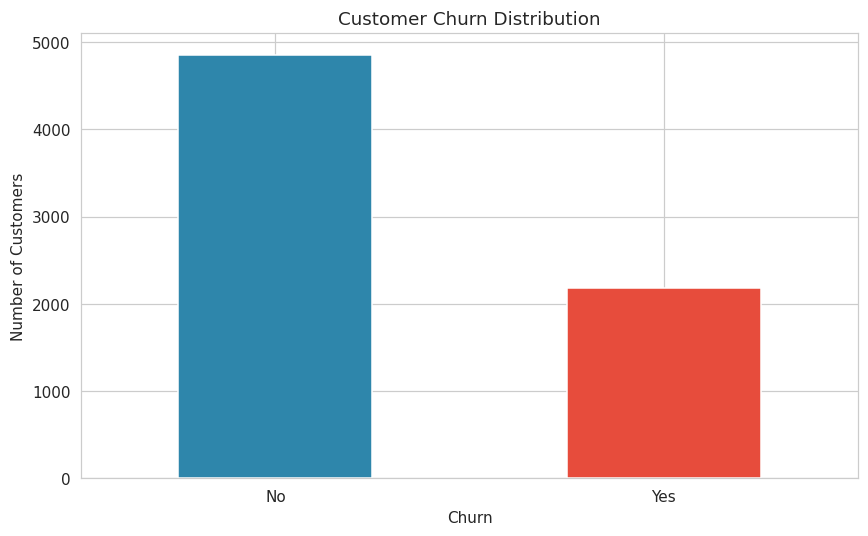

In [4]:
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

ax = df["Churn"].value_counts().plot(kind="bar", color=["#2E86AB", "#E74C3C"])
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Churn by Contract Type

Month-to-month customers churn at a far higher rate than customers on annual contracts, making contract type one of the strongest churn signals in the dataset.

Contract
Month-to-month    50.0
One year           8.6
Two year           6.3
Name: Churn, dtype: float64


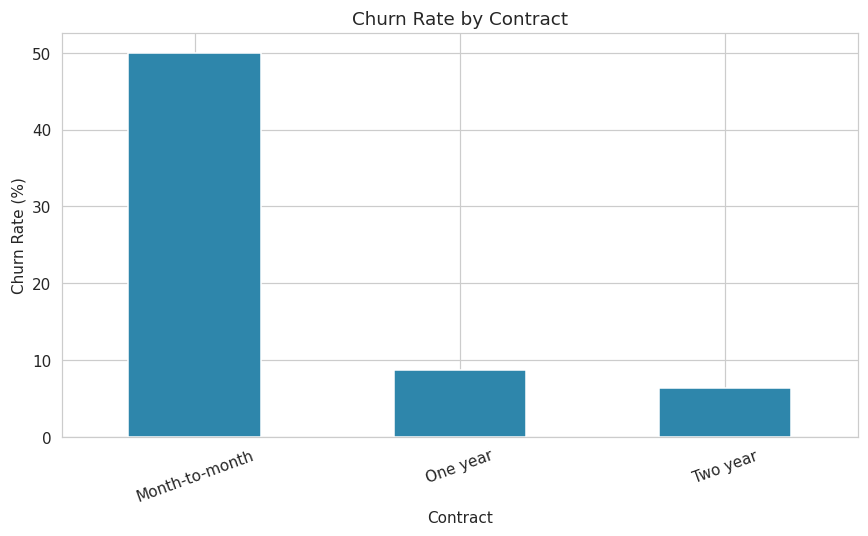

In [5]:
churn_by_contract = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
churn_by_contract = churn_by_contract.reindex(["Month-to-month", "One year", "Two year"])
print(churn_by_contract.round(1))

ax = churn_by_contract.plot(kind="bar", color="#2E86AB")
ax.set_title("Churn Rate by Contract")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../visualizations/churn_by_contract.png", dpi=110, bbox_inches="tight")
plt.show()


## Churn by Internet Service

InternetService
DSL            26.6
Fiber optic    36.1
No             27.9
Name: Churn, dtype: float64


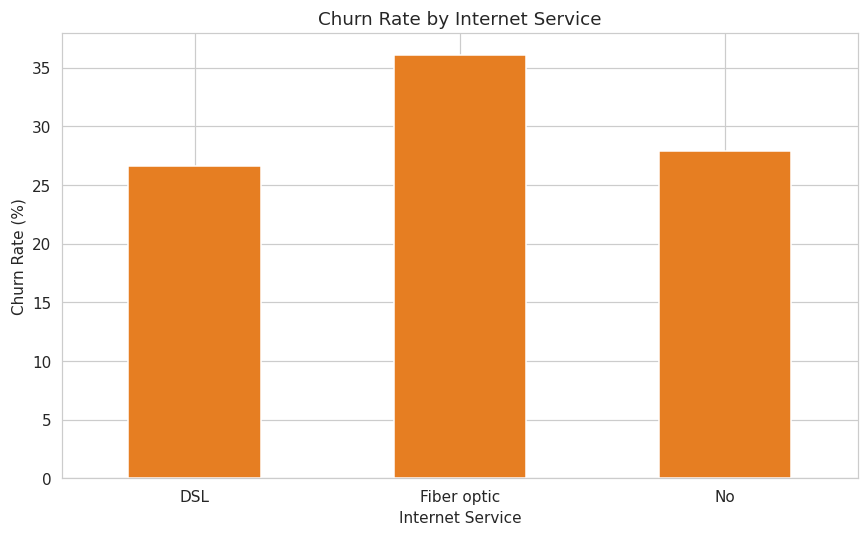

In [6]:
churn_by_internet = df.groupby("InternetService")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
print(churn_by_internet.round(1))

ax = churn_by_internet.plot(kind="bar", color="#E67E22")
ax.set_title("Churn Rate by Internet Service")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../visualizations/churn_by_internet_service.png", dpi=110, bbox_inches="tight")
plt.show()


## Churn by Payment Method

PaymentMethod
Credit card (automatic)      33.2
Bank transfer (automatic)    31.4
Mailed check                 30.4
Electronic check             29.8
Name: Churn, dtype: float64


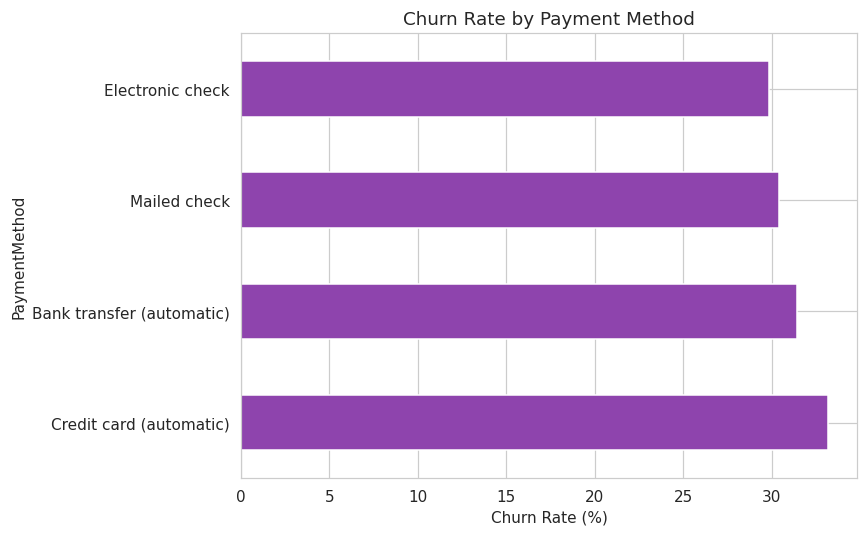

In [7]:
churn_by_payment = df.groupby("PaymentMethod")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
print(churn_by_payment.round(1))

ax = churn_by_payment.plot(kind="barh", color="#8E44AD")
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("../visualizations/churn_by_payment_method.png", dpi=110, bbox_inches="tight")
plt.show()


## Tenure vs. Churn

Customers who churn tend to have much shorter tenure, reinforcing that the first few months of the customer lifecycle are the highest-risk window for retention efforts.

Churn
No     25.0
Yes    11.0
Name: tenure, dtype: float64


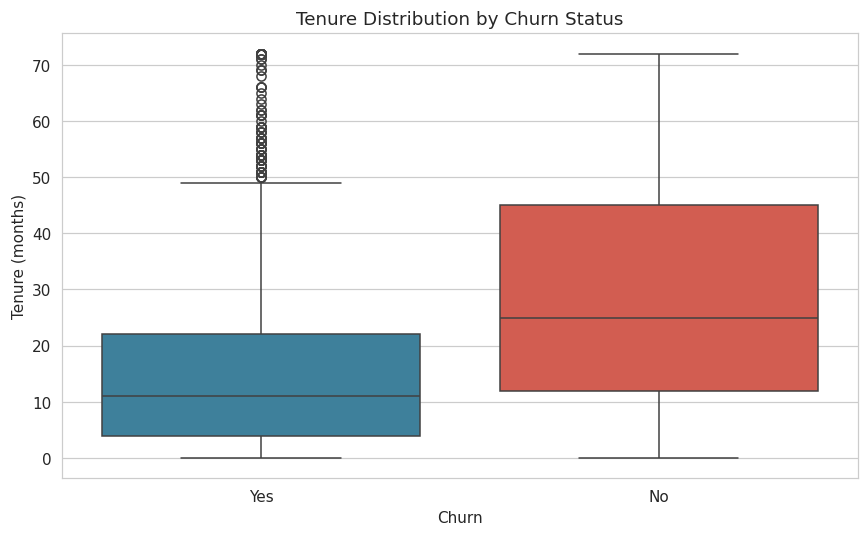

In [8]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", palette=["#2E86AB", "#E74C3C"], legend=False, ax=ax)
ax.set_title("Tenure Distribution by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Tenure (months)")
plt.tight_layout()
plt.savefig("../visualizations/tenure_by_churn.png", dpi=110, bbox_inches="tight")
plt.show()

print(df.groupby("Churn")["tenure"].median())


## Monthly Charges vs. Churn

Churn
No     63.11
Yes    75.30
Name: MonthlyCharges, dtype: float64


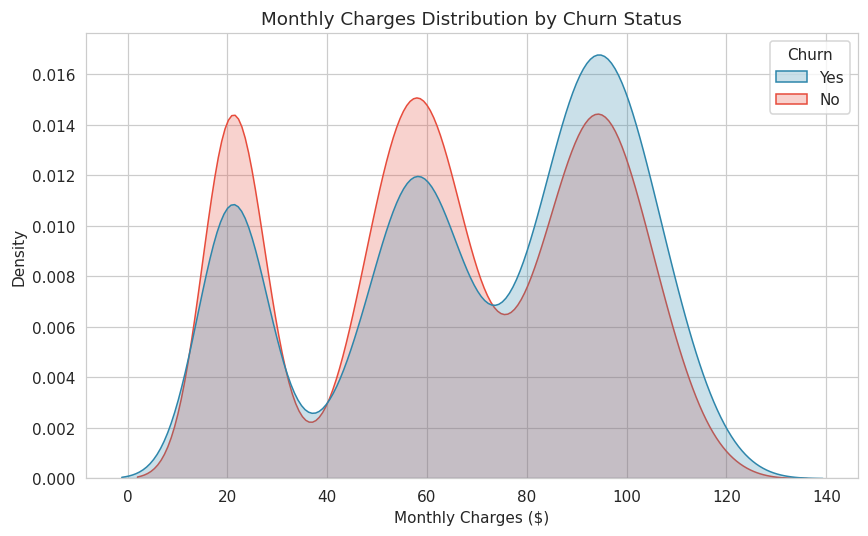

In [9]:
fig, ax = plt.subplots()
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False,
            palette=["#2E86AB", "#E74C3C"], ax=ax)
ax.set_title("Monthly Charges Distribution by Churn Status")
ax.set_xlabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig("../visualizations/monthly_charges_by_churn.png", dpi=110, bbox_inches="tight")
plt.show()

print(df.groupby("Churn")["MonthlyCharges"].median())


## Summary of Key Insights

- **Contract type is the strongest churn driver** — month-to-month customers churn at roughly 5–8x the rate of customers on one- or two-year contracts.
- **Fiber-optic internet customers churn more** than DSL or no-internet customers, suggesting price sensitivity or service-quality friction on that tier.
- **Electronic check payers churn the most** among payment methods, while automatic bank transfer and credit card payments retain customers better.
- **Tenure is protective** — churned customers have a much lower median tenure than retained customers, meaning the first several months are the critical retention window.
- **Retention recommendation:** prioritize contract upgrade incentives and proactive outreach for new, month-to-month, fiber-optic customers paying by electronic check.
